# 02 — Fundability model (ACTION × CITY → FINANCE)

The four-layer model. Reads the action catalog, the SINIM/Censo municipal-capacity layer, the **local** finance inventory (`data/chile_finance_inventory.csv`, produced by `01_finance_inventory.ipynb`), and the projects pipeline; emits a route/effort bucket + `financial_feasibility` score per (action × comuna), and the per-action coverage matrix. See `methodology.md` (Part B).

# Climate-action fundability — 4-layer prototype (v1)

Brings the four layers together into a **route/effort label** per (action × comuna): ACTION (catalog) × CITY (SINIM+INE) → interaction, FINANCE resolves to named funds, PROJECTS gives precedent. See `../../methodology.md`.

**Design choices baked in here:** action difficulty is derived from the catalog's own `primary_intervention` archetype (no SSG dependency, portable); capacity & autonomy are **continuous 0–1 scores**; the thresholds are **tunable parameters**; low-cost actions stay flat across comunas by construction. Output is a categorisation, **not a funding probability**.

In [1]:
import pandas as pd, numpy as np, json, re
import matplotlib.pyplot as plt
R="../../../../"   # repo reviews/ root from this notebook
A=pd.read_csv(R+"cl-ssg/cl-ssg-projects/releases/v1/data/derived/actions_profiled.csv"); A.columns=[c.strip().lstrip('\ufeff') for c in A.columns]
CITY=pd.read_csv(R+"cl-subdere/cl-subdere-sinim/releases/v1/data/municipal_who_features_2025.csv", dtype={"comuna_cut":str})
FIN=pd.read_csv(R+"oef/cl-city-action-fundability/releases/v1/data/chile_finance_inventory.csv")
MATCH=pd.read_csv(R+"cl-ssg/cl-ssg-projects/releases/v1/data/derived/project_action_matches.csv")
Y="2025"
print("actions",len(A),"| comunas",len(CITY),"| funds",len(FIN))

actions 102 | comunas 345 | funds 99


## 1. ACTION tags — from `primary_intervention` (backfilled from channel), no SSG

In [2]:
def arch_from_channel(ch):
    ch=str(ch)
    if re.search(r"regulation|standard|enforce",ch): return "regulatory"
    if re.search(r"financial_incentive|subsidy",ch): return "financial"
    if re.search(r"tod|urban_form|zoning",ch): return "planning"
    if re.search(r"building|industrial_process|biogas|composting|mbt|eco_park|landfill|renewable|solar|grid|fleet|bus|freight|rail|forest|soil|livestock|wastewater|recycling",ch): return "infrastructure"
    return np.nan
A["archetype"]=A["primary_intervention"]
m=A["archetype"].isna(); A.loc[m,"archetype"]=A.loc[m,"primary_channel"].map(arch_from_channel); A["archetype"]=A["archetype"].fillna("program")
FORM={"regulatory":0.2,"planning":0.5,"program":0.5,"financial":0.5,"infrastructure":0.8}   # tunable
CAP ={"low":0.2,"medium":0.5,"high":0.8}                                                     # tunable
A["formulation_demand"]=A["archetype"].map(FORM)
A["capital_demand"]=A["investment_cost"].map(CAP).fillna(0.5)
A.loc[(A.archetype=="infrastructure")&(A.investment_cost=="high"),"formulation_demand"]=0.9
romap={"I":"stationary_energy","II":"transportation","III":"waste","IV":"industry","V":"afolu"}
A["sector"]=A["gpc_reference_number"].map(lambda x:(lambda mm: romap.get(mm.group(1)) if mm else None)(re.search(r"(IV|III|II|I|V)",str(x).upper())))
print(A["archetype"].value_counts().to_string()); print("\nsector resolved:",A.sector.notna().sum(),"/",len(A))
A[["action_name","archetype","investment_cost","capital_demand","formulation_demand","sector"]].head(6)

archetype
infrastructure    48
program           23
regulatory        17
planning           7
financial          7

sector resolved: 102 / 102


,action_name,archetype,investment_cost,capital_demand,formulation_demand,sector
0,Introduce energy-efficiency standards for new ...,regulatory,low,0.2,0.2,stationary_energy
1,Introduce energy-efficiency standards for new ...,regulatory,low,0.2,0.2,stationary_energy
2,Support Implementation of Industrial Building ...,regulatory,low,0.2,0.2,stationary_energy
3,Retrofit residential buildings for energy effi...,infrastructure,low,0.2,0.8,stationary_energy
4,Retrofit commercial and institutional other no...,infrastructure,low,0.2,0.8,stationary_energy
5,Retrofit municipal buildings for energy effici...,infrastructure,low,0.2,0.8,stationary_energy


## 2. CITY scores — continuous autonomy & capacity (0–1)

In [3]:
c=CITY.copy()
c["autonomy"]=(1-c[f"fcm_dependency_pct_{Y}"]/100).clip(0,1)            # higher = more own-money
pr=lambda s:s.rank(pct=True)
c["capacity"]=0.7*pr(c[f"staff_profesional_total_{Y}"])+0.3*pr(c[f"professionalization_pct_{Y}"])  # tunable blend
c["autonomy"]=c["autonomy"].fillna(c["autonomy"].median()); c["capacity"]=c["capacity"].fillna(c["capacity"].median())
print(c[["autonomy","capacity"]].describe().round(2).T.to_string())

          count  mean   std   min   25%   50%   75%   max
autonomy  345.0  0.36  0.22  0.01  0.20  0.29  0.50  0.98
capacity  345.0  0.50  0.19  0.01  0.36  0.50  0.66  0.96


## 3. FINANCE — usable, municipality-eligible funds by sector

In [4]:
FIN["secs"]=FIN["gpc_sectors"].map(lambda x:(json.loads(x) if isinstance(x,str) and x.startswith('[') else []))
ea=FIN["eligible_actor"].str.lower().fillna(""); FIN["muni_ok"]=ea.str.contains("municip")&~ea.str.contains("not municip")
FIN["usable"]=FIN["status"].str.contains("open|rolling",case=False,na=False)|FIN["recurrence"].isin(["annual","ongoing"])
FIN["direct"]=FIN["access_pathway"].str.contains("direct",case=False,na=False)
def funds_for(sec):
    return FIN.iloc[0:0] if sec is None else FIN[FIN["secs"].apply(lambda s: sec in s or "cross_sector" in s)&FIN.muni_ok&FIN.usable]
def fund_names(sec,n=2):
    f=funds_for(sec)
    return "(no usable city-eligible fund — gap)" if len(f)==0 else ", ".join(f.program_name.head(n))[:55]+(" [direct]" if f.direct.any() else " [competitive]")
print({s:len(funds_for(s)) for s in ["stationary_energy","transportation","waste","afolu","industry"]})

{'stationary_energy': 4, 'transportation': 2, 'waste': 13, 'afolu': 5, 'industry': 2}


## 4. INTERACTION → route label  (tunable threshold)

Low-capital actions are flat across comunas by construction (money isn't the constraint). Otherwise a shortfall on the axis the action stresses sets the route.

In [5]:
def route(cap_d,form_d,auto,cap,thr=0.05):
    dg=(form_d-cap)>thr
    if cap_d<=0.2: return "needs technical assistance" if dg else "self-deliverable"
    mg=(cap_d-auto)>thr
    if not mg and not dg: return "own-budget feasible"
    if mg and not dg: return "needs external co-finance"
    if dg and not mg: return "needs technical assistance"
    return "needs external finance + TA / pooling"
ORDER=["self-deliverable","own-budget feasible","needs technical assistance","needs external co-finance","needs external finance + TA / pooling"]

## 5. How it looks together — route mix across all 102 actions, per comuna

,autonomy,capacity
comuna,,
Iquique,0.84,0.74
Camiña,0.01,0.50
La Pintana,0.19,0.68
Las Condes,0.98,0.95


,Las Condes,Iquique,La Pintana,Camiña
self-deliverable,25,17,17,17
own-budget feasible,77,37,0,0
needs technical assistance,0,48,8,8
needs external co-finance,0,0,37,37
needs external finance + TA / pooling,0,0,40,40


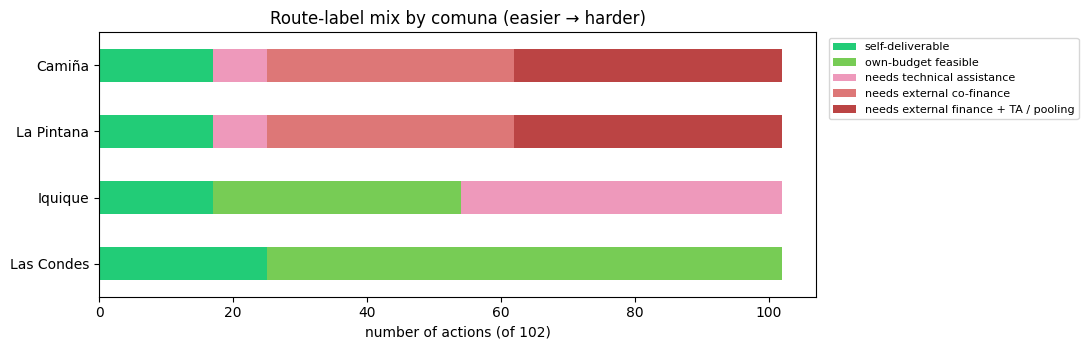

In [6]:
examples=["Las Condes","Iquique","La Pintana","Camiña"]
ex=c[c.comuna.isin(examples)].set_index("comuna")
mix={n:pd.Series([route(a.capital_demand,a.formulation_demand,ex.loc[n].autonomy,ex.loc[n].capacity) for a in A.itertuples()]).value_counts() for n in examples}
mixdf=pd.DataFrame(mix).reindex(ORDER).fillna(0).astype(int)
display(ex[["autonomy","capacity"]].round(2)); display(mixdf)
colors=["#2c7","#7c5","#e9b","#d77","#b44"]
ax=mixdf.T.plot(kind="barh",stacked=True,color=colors,figsize=(11,3.6))
ax.set_xlabel("number of actions (of 102)"); ax.set_title("Route-label mix by comuna (easier → harder)")
ax.legend(bbox_to_anchor=(1.01,1),fontsize=8); plt.tight_layout(); plt.show()

## 6. Concrete (action × comuna) with resolved funds

In [7]:
pick=A[A.action_name.str.contains("institutional buildings|Electrify municipal|segregated|Inefficient Lighting|solar generation",case=False,na=False)].drop_duplicates("action_name").head(4)
rows=[{"action":a.action_name[:30],"arch":a.archetype,"cap":a.capital_demand,"form":a.formulation_demand,"comuna":n,
       "route":route(a.capital_demand,a.formulation_demand,ex.loc[n].autonomy,ex.loc[n].capacity),"funds":fund_names(a.sector)}
      for a in pick.itertuples() for n in examples]
pd.DataFrame(rows)

,action,arch,cap,form,comuna,route,funds
0,Introduce energy-efficiency st,regulatory,0.2,0.2,Las Condes,self-deliverable,"Casa Solar, Programa de Mejoramiento Urbano y ..."
1,Introduce energy-efficiency st,regulatory,0.2,0.2,Iquique,self-deliverable,"Casa Solar, Programa de Mejoramiento Urbano y ..."
2,Introduce energy-efficiency st,regulatory,0.2,0.2,La Pintana,self-deliverable,"Casa Solar, Programa de Mejoramiento Urbano y ..."
3,Introduce energy-efficiency st,regulatory,0.2,0.2,Camiña,self-deliverable,"Casa Solar, Programa de Mejoramiento Urbano y ..."
4,Electrify municipal vehicle fl,infrastructure,0.8,0.9,Las Condes,own-budget feasible,Programa de Mejoramiento Urbano y Equipamiento...
5,Electrify municipal vehicle fl,infrastructure,0.8,0.9,Iquique,needs technical assistance,Programa de Mejoramiento Urbano y Equipamiento...
6,Electrify municipal vehicle fl,infrastructure,0.8,0.9,La Pintana,needs external finance + TA / pooling,Programa de Mejoramiento Urbano y Equipamiento...
7,Electrify municipal vehicle fl,infrastructure,0.8,0.9,Camiña,needs external finance + TA / pooling,Programa de Mejoramiento Urbano y Equipamiento...
8,Implement residential and busi,program,0.5,0.5,Las Condes,own-budget feasible,"FPR 2026 - Fondo para el Reciclaje, FPR 2025 –..."
9,Implement residential and busi,program,0.5,0.5,Iquique,own-budget feasible,"FPR 2026 - Fondo para el Reciclaje, FPR 2025 –..."


## 7. Reading & open calibration

- **Low-cost actions are flat** (self-deliverable everywhere) — they don't differentiate and never down-rank a weak comuna.
- **Demanding actions diverge** — own-budget for self-starters, "needs co-finance / TA / pooling" for cash-tight or thin comunas.
- **Funds resolve** by sector × municipality-eligibility × usability, with access-pathway (`[direct]` vs `[competitive]`) flagged.
- **Output is a route, not a probability**; finance amounts and award odds are out of scope.

**Tunable parameters** (move these, not the comuna labels): the `FORM`/`CAP` demand maps, the capacity blend (0.7/0.3), and the gap `thr`. **To watch:** La Pintana and Camiña land on the same mix here — capacity only bites between the demand bands, so the capacity blend / thresholds are the next thing to calibrate. **Out of scope still:** finance amounts (adequacy) and award odds.

## 8. `financial_feasibility` score — the HIAP Feasibility leg

Map the route (blended with fund access) to a 0–1 score that can plug into HIAP's **Feasibility** pillar as a third leg (legal · mitigation · **financial**). Ordinal/coarse by design; `0.5` neutral default for cities with no data (matches HIAP's missing-legal-verdict rule). Lives in Feasibility (~0.23 of final) so it nudges, never swamps Impact.

In [8]:
prec=MATCH.groupby("action_id").size().rename("n_existing_projects")
A=A.merge(prec,on="action_id",how="left"); A["n_existing_projects"]=A["n_existing_projects"].fillna(0).astype(int)
def access(sec):
    f=funds_for(sec)
    return "gap" if len(f)==0 else ("direct" if f.direct.any() else "competitive")
A["fund_access"]=A["sector"].map(access)
def ffscore(rt,acc):
    base={"self-deliverable":1.0,"own-budget feasible":0.85,"needs technical assistance":0.70}
    if rt in base: return base[rt]
    if rt=="needs external co-finance": return {"direct":0.60,"competitive":0.45,"gap":0.25}[acc]
    return {"direct":0.35,"competitive":0.30,"gap":0.15}[acc]
rows=[]
for cc in c.itertuples():            # FULL run: all 345 comunas
    a0=cc
    for a in A.itertuples():
        rt=route(a.capital_demand,a.formulation_demand,a0.autonomy,a0.capacity)
        rows.append(dict(comuna_cut=cc.comuna_cut,comuna=cc.comuna,autonomy=round(a0.autonomy,2),capacity=round(a0.capacity,2),action_id=a.action_id,
                         action_name=a.action_name,archetype=a.archetype,sector=a.sector,capital_demand=a.capital_demand,
                         formulation_demand=a.formulation_demand,route=rt,fund_access=a.fund_access,
                         financial_feasibility=ffscore(rt,a.fund_access),n_existing_projects=a.n_existing_projects))
scored=pd.DataFrame(rows)
scored.to_csv("data/fundability_scored.csv",index=False)
print("wrote data/fundability_scored.csv",scored.shape); scored.head(4)

wrote data/fundability_scored.csv (35190, 14)


,comuna_cut,comuna,autonomy,capacity,action_id,action_name,archetype,sector,capital_demand,formulation_demand,route,fund_access,financial_feasibility,n_existing_projects
0,01101,Iquique,0.84,0.74,c40_0010,Introduce energy-efficiency standards for new ...,regulatory,stationary_energy,0.2,0.2,self-deliverable,competitive,1.0,5
1,01101,Iquique,0.84,0.74,c40_0012,Introduce energy-efficiency standards for new ...,regulatory,stationary_energy,0.2,0.2,self-deliverable,competitive,1.0,0
2,01101,Iquique,0.84,0.74,c40_0013,Support Implementation of Industrial Building ...,regulatory,stationary_energy,0.2,0.2,self-deliverable,competitive,1.0,0
3,01101,Iquique,0.84,0.74,c40_0015,Retrofit residential buildings for energy effi...,infrastructure,stationary_energy,0.2,0.8,needs technical assistance,competitive,0.7,73


## 9. Review — does the output make sense?

In [9]:
print("[1] ff by comuna (mean/min/max):"); print(scored.groupby("comuna").financial_feasibility.agg(['mean','min','max']).round(2).to_string())
print("\n[2] corr(ff, capital_demand)=",round(scored.financial_feasibility.corr(scored.capital_demand),2),
      "| corr(ff, autonomy)=",round(scored.financial_feasibility.corr(scored.autonomy),2),"  (expect <0 and >0)")
print("\n[3] mean ff by archetype (Iquique) — expect infra lowest, regulatory highest:")
print(scored[scored.comuna=='Iquique'].groupby('archetype').financial_feasibility.mean().round(2).sort_values().to_string())
print("\n[4] sanity: high-capital action scoring >=0.85 in a low-autonomy comuna (expect 0):",
      len(scored[(scored.comuna.isin(['Camiña','La Pintana']))&(scored.capital_demand>=0.8)&(scored.financial_feasibility>=0.85)]))
print("\n[5] archetype vs cost audit — 'regulatory' actions that carry non-low investment_cost:")
reg=A[A.archetype=='regulatory']; print((reg.investment_cost!='low').sum(),"of",len(reg),"regulatory actions are medium/high cost")
print("\n[6] fund coverage by sector (thin coverage = 'competitive' does heavy lifting; amounts not assessed):")
print({s:len(funds_for(s)) for s in ['stationary_energy','transportation','waste','afolu','industry']})

[1] ff by comuna (mean/min/max):
                      mean   min  max
comuna                               
Algarrobo             0.80  0.70  1.0
Alhué                 0.74  0.70  1.0
Alto Biobío           0.46  0.30  1.0
Alto Del Carmen       0.53  0.30  1.0
Alto Hospicio         0.53  0.30  1.0
Ancud                 0.53  0.30  1.0
Andacollo             0.41  0.30  0.7
Angol                 0.53  0.30  1.0
Antofagasta           0.86  0.70  1.0
Antuco                0.46  0.30  1.0
Arauco                0.53  0.30  1.0
Arica                 0.53  0.30  1.0
Aysén                 0.53  0.30  1.0
Buin                  0.68  0.30  1.0
Bulnes                0.46  0.30  1.0
Cabildo               0.53  0.30  1.0
Cabo De Hornos        0.46  0.30  1.0
Cabrero               0.53  0.30  1.0
Calama                0.68  0.30  1.0
Calbuco               0.53  0.30  1.0
Caldera               0.46  0.30  1.0
Calera                0.53  0.30  1.0
Calera De Tango       0.68  0.30  1.0
Calle Larga      

**Review conclusion.** Signs are right (ff falls with capital intensity r≈−0.47, rises with autonomy r≈+0.66); archetype ordering is intuitive (infrastructure hardest → regulatory easiest); no bug cases (no high-capital action scores high in a weak comuna). 

Three honest wrinkles, all known/tunable: (a) **La Pintana ≈ Camiña** — capacity only bites between demand bands, so the capacity blend/thresholds are the next calibration; (b) a handful of **'regulatory'-tagged actions carry medium/high `investment_cost`**, so the archetype is not a perfect proxy — audit those tags; (c) **thin fund coverage** in transport/industry/afolu means 'competitive' carries the signal and **adequacy (amounts) is not assessed** — availability bias caveat from the finance methodology still applies.

## 10. Sensitivity — does within-city ranking depend on the experts' band values?

The demand bands are expert priors with low confidence in exact values. Test: jitter every band by ±0.1 and check whether the *order of actions inside each comuna* is stable (within-city ordering is the objective — §0). Two variants of the low-cost gate.

In [10]:
arche=A.archetype.values; inv=A.investment_cost.fillna('medium').values; accv=A.fund_access.values
FFCO={'direct':(0.60,0.35),'competitive':(0.45,0.30),'gap':(0.25,0.15)}
def ffv(form,capd,auto,cap,ordinal_low,thr=0.05):
    low=(inv=='low') if ordinal_low else (capd<=0.2)
    dg=(form-cap)>thr; mg=(capd-auto)>thr; o=np.empty(len(form))
    for i in range(len(form)):
        if low[i]: o[i]=0.70 if dg[i] else 1.0
        elif (not mg[i]) and (not dg[i]): o[i]=0.85
        elif mg[i] and not dg[i]: o[i]=FFCO[accv[i]][0]
        elif dg[i] and not mg[i]: o[i]=0.70
        else: o[i]=FFCO[accv[i]][1]
    return o
bf={'regulatory':0.2,'planning':0.5,'program':0.5,'financial':0.5,'infrastructure':0.8}; bc={'low':0.2,'medium':0.5,'high':0.8}
def mk(fm,cm):
    f=np.array([fm[a] for a in arche]); cc=np.array([cm[i] for i in inv]); return np.where((arche=='infrastructure')&(inv=='high'),0.9,f),cc
srank=lambda x: pd.Series(x).rank().values
spz=lambda a,b: 1.0 if srank(a).std()==0 or srank(b).std()==0 else np.corrcoef(srank(a),srank(b))[0,1]
rng=np.random.default_rng(0); rows=c[['comuna','autonomy','capacity']].values; K=80
def run(ol):
    fb,cb=mk(bf,bc); base={r[0]:ffv(fb,cb,r[1],r[2],ol) for r in rows}; T=[]
    jit=lambda d:{k:float(np.clip(v+rng.normal(0,0.1),0.05,0.95)) for k,v in d.items()}
    for r in rows:
        b=base[r[0]]
        for _ in range(K):
            f2,c2=mk(jit(bf),jit(bc)); T.append(spz(b,ffv(f2,c2,r[1],r[2],ol)))
    return np.array(T)
for ol,lbl in [(False,'current (hard 0.2 cutoff)'),(True,'ordinal low-cost gate (recommended)')]:
    t=run(ol); print(f"{lbl:38s} median within-city Spearman={np.median(t):.3f}  p10={np.percentile(t,10):.3f}")

current (hard 0.2 cutoff)              median within-city Spearman=0.943  p10=0.601


ordinal low-cost gate (recommended)    median within-city Spearman=1.000  p10=0.698


**Conclusion.** With the ordinal low-cost gate, within-city ranking is **invariant to ±0.1 band jitter (median Spearman ≈ 1.0)** — so the experts' exact magnitudes are *not* load-bearing; only their rank order is. Keep the expert values; treat the magnitudes as non-critical. Residual sensitivity is confined to comunas whose autonomy/capacity sits on a band edge. **Recommended hardening:** key the low-cost branch off `investment_cost=='low'` rather than the numeric `0.2` (changes no baseline output).

## Coverage matrix (gap dashboard)

One row per action: does it have a sector-specific municipal route, an award precedent, a BIP precedent, a cost benchmark, and fund amounts? Built from the scored output above (deduplicated to action level) plus the finance inventory, so no separate action-tags file is needed. Empty cells are the backlog; see methodology §9a. Writes `data/action_coverage_matrix.csv` and renders the coverage heatmap inline.

In [11]:
# --- coverage matrix: derive action-level frame from the scored output (no action_tags.csv dependency) ---
import json
_R="../../../.."  # reviews/ root (matches R; relative to releases/v1)
_scored=pd.read_csv("data/fundability_scored.csv")
acts=(_scored.sort_values("action_id").drop_duplicates("action_id")
      [["action_id","action_name","archetype","sector","capital_demand","n_existing_projects"]]
      .reset_index(drop=True))
fin=pd.read_csv(f"{_R}/oef/cl-city-action-fundability/releases/v1/data/chile_finance_inventory.csv")
AWARD_SECTORS={"afolu"}   # only CONAF Bosque Nativo awards exist today
def _secs(s):
    try: return set(json.loads(s))
    except: return {str(s)}
fin["secs"]=fin["gpc_sectors"].map(_secs)
fin["is_muni"]=fin["eligible_actor"].str.lower().str.contains("municipalit|regional",na=False,regex=True)
fin["has_amt"]=fin["amount_clp"].fillna(0).astype(float)>0
rows=[]
for _,a in acts.iterrows():
    sec=a["sector"]
    match=fin[fin["secs"].apply(lambda S: sec in S or "cross_sector" in S)]
    muni=match[match["is_muni"]]
    muni_specific=fin[fin["secs"].apply(lambda S: sec in S) & fin["is_muni"]]
    n_proj=0 if pd.isna(a["n_existing_projects"]) else int(float(a["n_existing_projects"]))
    has_specific=len(muni_specific)>0; has_bip=n_proj>0; has_award=sec in AWARD_SECTORS
    status=("well-covered" if has_specific and has_bip else "route-only" if has_specific
            else "precedent-only (broad funds only)" if has_bip else "thin (broad funds only, no precedent)")
    gaps=[g for g,ok in [("only broad/cross-sector funds",has_specific),("no BIP precedent",has_bip),
          ("no award precedent",has_award),("no fund amounts",match["has_amt"].any())] if not ok]
    rows.append(dict(action_id=a["action_id"],action_name=a["action_name"],sector=sec,archetype=a["archetype"],
        capital_demand=a["capital_demand"],n_funds_any=len(match),n_funds_muni=len(muni),
        n_funds_muni_specific=len(muni_specific),n_funds_with_amount=int(match["has_amt"].sum()),
        has_supply_route_any=len(muni)>0,has_specific_route=has_specific,has_award_precedent=has_award,
        n_existing_projects=n_proj,has_bip_precedent=has_bip,has_cost_benchmark=has_bip or has_award,
        coverage_status=status,gaps="; ".join(gaps) or "none"))
cov=pd.DataFrame(rows)
assert len(cov)==102, len(cov)
cov.to_csv("data/action_coverage_matrix.csv",index=False)
print("sector-specific route:",int(cov.has_specific_route.sum()),
      "| BIP precedent:",int(cov.has_bip_precedent.sum()),
      "| award precedent:",int(cov.has_award_precedent.sum()))
cov["coverage_status"].value_counts()

sector-specific route: 76 | BIP precedent: 77 | award precedent: 27


coverage_status
well-covered                             66
thin (broad funds only, no precedent)    15
precedent-only (broad funds only)        11
route-only                               10
Name: count, dtype: int64

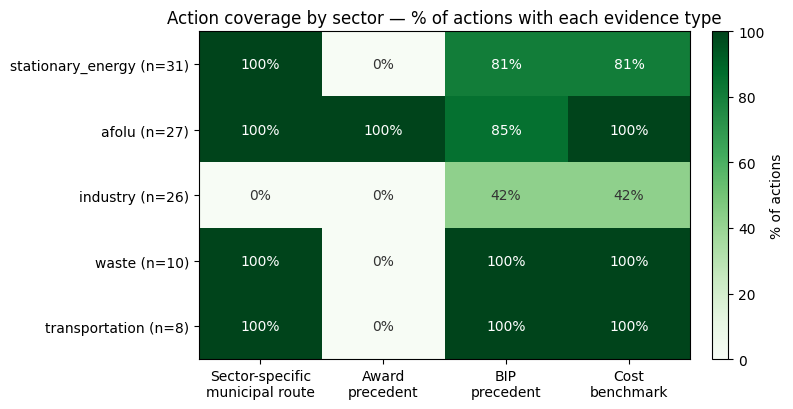

In [12]:
# --- coverage heatmap (inline; not saved as a file) ---
import numpy as np, matplotlib.pyplot as plt
ev={"Sector-specific\nmunicipal route":"has_specific_route","Award\nprecedent":"has_award_precedent",
    "BIP\nprecedent":"has_bip_precedent","Cost\nbenchmark":"has_cost_benchmark"}
sectors=cov["sector"].value_counts().index.tolist()
H=np.array([[100*cov.loc[cov.sector==s,c].mean() for c in ev.values()] for s in sectors])
fig,ax=plt.subplots(figsize=(8,4.2))
im=ax.imshow(H,cmap="Greens",vmin=0,vmax=100,aspect="auto")
ax.set_xticks(range(len(ev))); ax.set_xticklabels(ev.keys())
ax.set_yticks(range(len(sectors))); ax.set_yticklabels([f"{s} (n={int((cov.sector==s).sum())})" for s in sectors])
for i in range(len(sectors)):
    for j in range(len(ev)):
        ax.text(j,i,f"{H[i,j]:.0f}%",ha="center",va="center",color="white" if H[i,j]>55 else "#333")
ax.set_title("Action coverage by sector — % of actions with each evidence type")
fig.colorbar(im,label="% of actions",fraction=.046,pad=.04); fig.tight_layout(); plt.show()